In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df_raw = pd.read_excel(r"C:\Users\EHidalgo\Downloads\Histórico_2025.xlsx")

df_raw.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,NaN,Total de información incompleta o de mala calidad,NaN,NaN,NaN,NaN,Veces en las que se puede solicitar la misma i...,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Mes,Personas,SIN CURP o\nMala capatura,%,NaN,Mes,Una vez,NaN,Dos veces,NaN,Tres veces,NaN
2,NaN,NaN,Número,Número,NaN,NaN,NaN,Número,%,Número,%,Número,%
3,NaN,Febrero,214,75,0.350467,NaN,Febrero,129,0.602804,8,0.037383,2,0.009346
4,NaN,Abril,236,78,0.330508,NaN,Abril,141,0.597458,14,0.059322,3,0.012712


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   0 non-null      float64
 1   Unnamed: 1   13 non-null     object 
 2   Unnamed: 2   13 non-null     object 
 3   Unnamed: 3   13 non-null     object 
 4   Unnamed: 4   12 non-null     object 
 5   Unnamed: 5   0 non-null      float64
 6   Unnamed: 6   13 non-null     object 
 7   Unnamed: 7   13 non-null     object 
 8   Unnamed: 8   12 non-null     object 
 9   Unnamed: 9   13 non-null     object 
 10  Unnamed: 10  12 non-null     object 
 11  Unnamed: 11  13 non-null     object 
 12  Unnamed: 12  12 non-null     object 
dtypes: float64(2), object(11)
memory usage: 1.5+ KB


In [4]:
data = {
    "Mes": ["Febrero","Abril","Mayo","Junio","Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre","Marzo"],
    "Personas":[214,236,226,351,168,328,261,1185,988,197,279],
    "Sin_CURP":[75,78,58,111,27,89,76,451,400,52,83],
    "Pct_bad":[0.350467,0.330508,0.256637,0.316239,0.160714,0.271341,0.291188,0.380591,0.404858,0.263959,0.297491],
    "Una_vez":[129,141,152,221,116,207,163,654,529,125,186],
    "Dos_veces":[8,14,13,10,15,23,17,71,49,6,6],
    "Tres_veces":[2,3,3,9,10,9,5,9,10,14,4]
}

df = pd.DataFrame(data)

df

,Mes,Personas,Sin_CURP,Pct_bad,Una_vez,Dos_veces,Tres_veces
0,Febrero,214,75,0.350467,129,8,2
1,Abril,236,78,0.330508,141,14,3
2,Mayo,226,58,0.256637,152,13,3
3,Junio,351,111,0.316239,221,10,9
4,Julio,168,27,0.160714,116,15,10
5,Agosto,328,89,0.271341,207,23,9
6,Septiembre,261,76,0.291188,163,17,5
7,Octubre,1185,451,0.380591,654,71,9
8,Noviembre,988,400,0.404858,529,49,10
9,Diciembre,197,52,0.263959,125,6,14


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Mes         11 non-null     object 
 1   Personas    11 non-null     int64  
 2   Sin_CURP    11 non-null     int64  
 3   Pct_bad     11 non-null     float64
 4   Una_vez     11 non-null     int64  
 5   Dos_veces   11 non-null     int64  
 6   Tres_veces  11 non-null     int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 744.0+ bytes


In [6]:
df.describe()

,Personas,Sin_CURP,Pct_bad,Una_vez,Dos_veces,Tres_veces
count,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,403.000000,136.363636,0.302181,238.454545,21.090909,7.090909
std,344.995362,145.006395,0.066831,179.903509,20.476594,3.858874
min,168.000000,27.000000,0.160714,116.000000,6.000000,2.000000
25%,220.000000,66.500000,0.267650,135.000000,9.000000,3.500000
50%,261.000000,78.000000,0.297491,163.000000,14.000000,9.000000
75%,339.500000,100.000000,0.340487,214.000000,20.000000,9.500000
max,1185.000000,451.000000,0.404858,654.000000,71.000000,14.000000


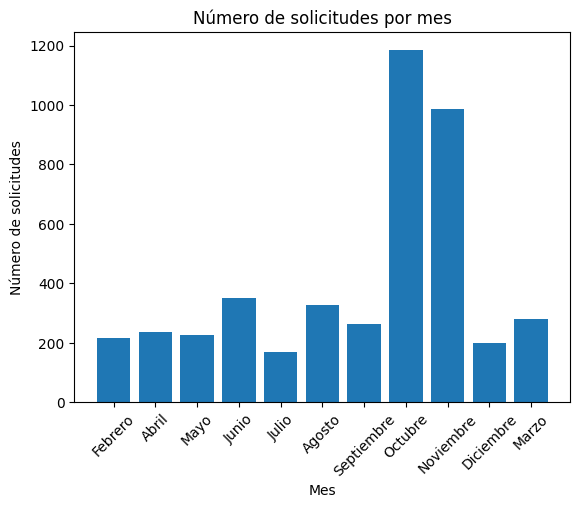

In [7]:
plt.figure()

plt.bar(df["Mes"], df["Personas"])

plt.title("Número de solicitudes por mes")
plt.xlabel("Mes")
plt.ylabel("Número de solicitudes")

plt.xticks(rotation=45)

plt.show()

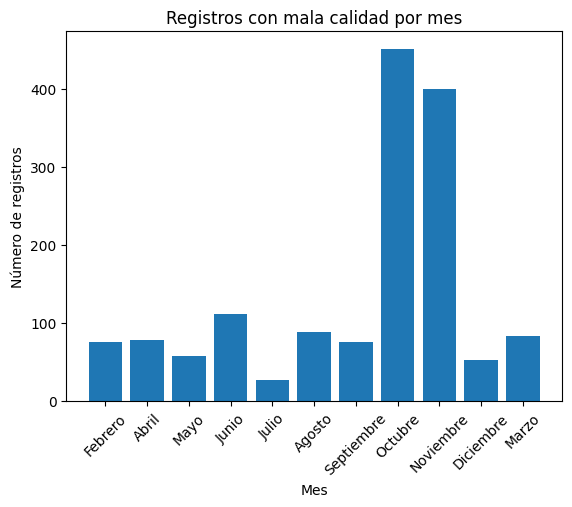

In [8]:
plt.figure()

plt.bar(df["Mes"], df["Sin_CURP"])

plt.title("Registros con mala calidad por mes")
plt.xlabel("Mes")
plt.ylabel("Número de registros")

plt.xticks(rotation=45)

plt.show()

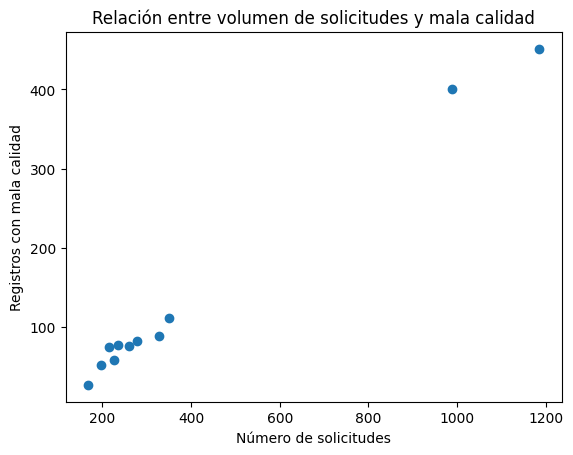

In [9]:
plt.figure()

plt.scatter(df["Personas"], df["Sin_CURP"])

plt.title("Relación entre volumen de solicitudes y mala calidad")
plt.xlabel("Número de solicitudes")
plt.ylabel("Registros con mala calidad")

plt.show()

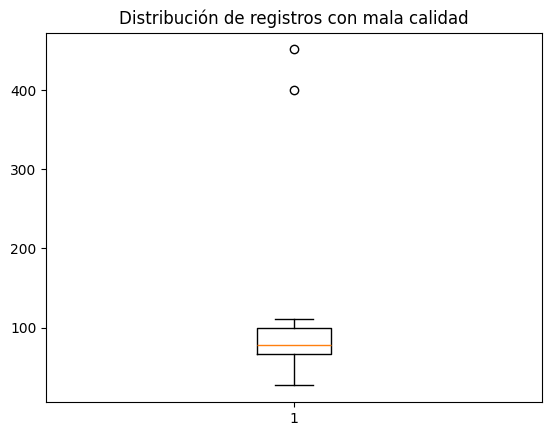

In [10]:
plt.figure()

plt.boxplot(df["Sin_CURP"])

plt.title("Distribución de registros con mala calidad")

plt.show()

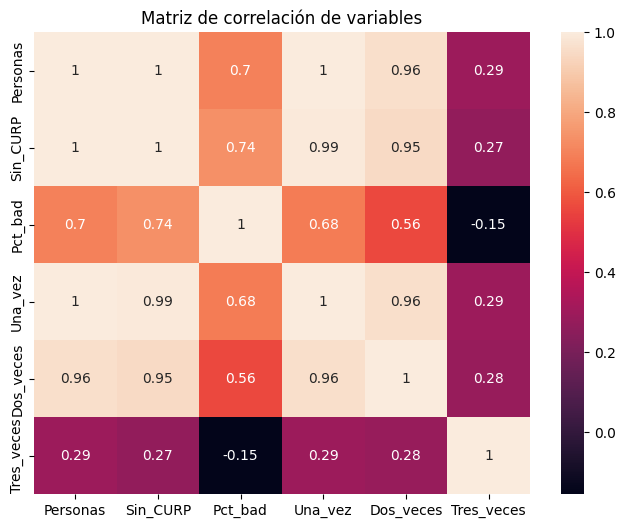

In [12]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Matriz de correlación de variables")

plt.show()

In [13]:
X = df[["Personas","Una_vez","Dos_veces","Tres_veces"]]

y = df["Sin_CURP"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
modelo_lr = LinearRegression()

modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

In [16]:
modelo_tree = DecisionTreeRegressor(random_state=42)

modelo_tree.fit(X_train, y_train)

pred_tree = modelo_tree.predict(X_test)

In [17]:
modelo_rf = RandomForestRegressor(random_state=42)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

In [18]:
def evaluar_modelo(y_real, y_pred):

    mae = mean_absolute_error(y_real, y_pred)

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    r2 = r2_score(y_real, y_pred)

    return mae, rmse, r2

In [19]:
mae_lr, rmse_lr, r2_lr = evaluar_modelo(y_test, pred_lr)

mae_tree, rmse_tree, r2_tree = evaluar_modelo(y_test, pred_tree)

mae_rf, rmse_rf, r2_rf = evaluar_modelo(y_test, pred_rf)

In [21]:
resultados = pd.DataFrame({

    "Modelo":[
        "Regresión Lineal",
        "Árbol de Decisión",
        "Random Forest"
    ],

    "MAE":[mae_lr, mae_tree, mae_rf],

    "RMSE":[rmse_lr, rmse_tree, rmse_rf],

    "R2":[r2_lr, r2_tree, r2_rf]

})

resultados

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,3.789561e-14,4.019437e-14,1.000000
1,Árbol de Decisión,2.133333e+01,2.158703e+01,-1.002865
2,Random Forest,1.044000e+01,1.070059e+01,0.507868


In [22]:
importancia = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
)

importancia.sort_values(ascending=False)

Personas      0.355187
Una_vez       0.351619
Dos_veces     0.234157
Tres_veces    0.059037
dtype: float64

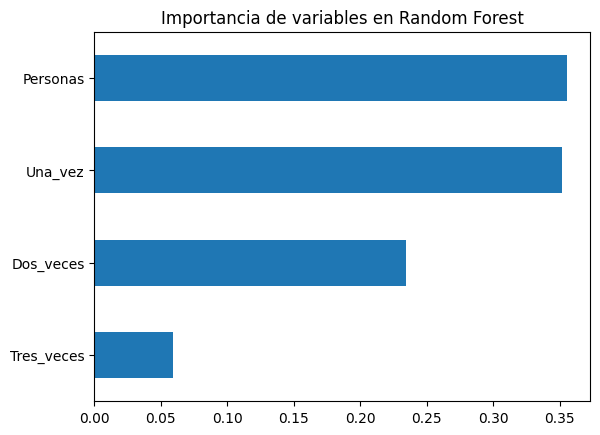

In [23]:
plt.figure()

importancia.sort_values().plot(kind='barh')

plt.title("Importancia de variables en Random Forest")

plt.show()